# DeepFace baseline for Task 2

This notebook tests the 20 selected images using DeepFace in Google Colab.

The predictions are converted into the project categories:

- age: Adult or Elderly
- gender: Male or Female
- expression: Happy or Sad

The same 20 images will later be tested in the iPhone application.


In [1]:
%pip install -q deepface==0.0.100 tf-keras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.3/51.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 79.8 MB/s eta 0:00:00


In [2]:
import os
import time
import shutil
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from deepface import DeepFace
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

26-07-18 05:08:58 - Directory /root/.deepface has been created
26-07-18 05:08:58 - Directory /root/.deepface/weights has been created
TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Upload and extract the dataset

Upload `edge_ai_dataset.zip` using the Files panel on the left side of Colab.  
It should appear at `/content/edge_ai_dataset.zip`.


In [4]:
zip_path = "/content/edge_ai_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_file:
    zip_file.extractall("/content")

data_path = "/content/edge_ai_dataset"
images_path = os.path.join(data_path, "images")
csv_path = os.path.join(data_path, "ground_truth.csv")

ground_truth = pd.read_csv(csv_path)
ground_truth

,image_id,filename,actual_age_group,actual_gender,actual_expression,notes
0,IMG01,IMG01.jpg,Adult,Male,Happy,NaN
1,IMG02,IMG02.jpg,Adult,Male,Happy,NaN
2,IMG03,IMG03.jpg,Adult,Male,Happy,NaN
3,IMG04,IMG04.jpg,Adult,Male,Sad,NaN
4,IMG05,IMG05.jpg,Adult,Male,Sad,NaN
5,IMG06,IMG06.jpg,Adult,Male,Sad,NaN
6,IMG07,IMG07.jpg,Adult,Female,Happy,NaN
7,IMG08,IMG08.jpg,Adult,Female,Happy,NaN
8,IMG09,IMG09.jpg,Adult,Female,Sad,NaN
9,IMG10,IMG10.jpg,Adult,Female,Sad,NaN


In [5]:
print(ground_truth["actual_age_group"].value_counts())
print()
print(ground_truth["actual_gender"].value_counts())
print()
print(ground_truth["actual_expression"].value_counts())

actual_age_group
Adult      10
Elderly    10
Name: count, dtype: int64

actual_gender
Male      10
Female    10
Name: count, dtype: int64

actual_expression
Happy    10
Sad      10
Name: count, dtype: int64


## Run DeepFace

The elderly threshold is set to 60 years.  
For expression, the Happy and Sad scores are compared directly.


In [6]:
ELDERLY_THRESHOLD = 60

def age_group(age):
    return "Elderly" if age >= ELDERLY_THRESHOLD else "Adult"

def gender_label(label):
    return "Male" if label.lower() in ["man", "male"] else "Female"

def expression_label(scores):
    return "Happy" if scores["happy"] >= scores["sad"] else "Sad"

The first image is analysed once before timing so that model loading does not affect the recorded inference time.


In [7]:
first_image = os.path.join(images_path, ground_truth.iloc[0]["filename"])

_ = DeepFace.analyze(
    img_path=first_image,
    actions=["age", "gender", "emotion"],
    detector_backend="opencv",
    enforce_detection=True,
    silent=True
)

print("Models are ready.")

26-07-18 05:10:09 - 🔗 age_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5 to /root/.deepface/weights/age_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/age_model_weights.h5
To: /root/.deepface/weights/age_model_weights.h5
100%|██████████| 539M/539M [00:05<00:00, 103MB/s]


26-07-18 05:10:18 - 🔗 gender_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5 to /root/.deepface/weights/gender_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/gender_model_weights.h5
To: /root/.deepface/weights/gender_model_weights.h5
100%|██████████| 537M/537M [00:08<00:00, 60.7MB/s]


26-07-18 05:10:28 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5
100%|██████████| 5.98M/5.98M [00:00<00:00, 126MB/s]


Models are ready.


In [8]:
results = []

for _, row in ground_truth.iterrows():
    image_path = os.path.join(images_path, row["filename"])

    try:
        start = time.perf_counter()

        analysis = DeepFace.analyze(
            img_path=image_path,
            actions=["age", "gender", "emotion"],
            detector_backend="opencv",
            enforce_detection=True,
            silent=True
        )[0]

        inference_ms = (time.perf_counter() - start) * 1000
        predicted_age = int(round(analysis["age"]))

        results.append({
            "image_id": row["image_id"],
            "filename": row["filename"],
            "actual_age_group": row["actual_age_group"],
            "predicted_age": predicted_age,
            "predicted_age_group": age_group(predicted_age),
            "actual_gender": row["actual_gender"],
            "predicted_gender": gender_label(analysis["dominant_gender"]),
            "actual_expression": row["actual_expression"],
            "deepface_emotion": analysis["dominant_emotion"].title(),
            "predicted_expression": expression_label(analysis["emotion"]),
            "happy_score": analysis["emotion"]["happy"],
            "sad_score": analysis["emotion"]["sad"],
            "inference_ms": inference_ms,
            "status": "Success"
        })

    except Exception as error:
        results.append({
            "image_id": row["image_id"],
            "filename": row["filename"],
            "actual_age_group": row["actual_age_group"],
            "predicted_age": np.nan,
            "predicted_age_group": np.nan,
            "actual_gender": row["actual_gender"],
            "predicted_gender": np.nan,
            "actual_expression": row["actual_expression"],
            "deepface_emotion": np.nan,
            "predicted_expression": np.nan,
            "happy_score": np.nan,
            "sad_score": np.nan,
            "inference_ms": np.nan,
            "status": str(error)
        })

results_df = pd.DataFrame(results)
results_df

,image_id,filename,actual_age_group,predicted_age,predicted_age_group,actual_gender,predicted_gender,actual_expression,deepface_emotion,predicted_expression,happy_score,sad_score,inference_ms,status
0,IMG01,IMG01.jpg,Adult,26,Adult,Male,Male,Happy,Happy,Happy,99.803535,3.361360e-08,6558.562009,Success
1,IMG02,IMG02.jpg,Adult,25,Adult,Male,Male,Happy,Happy,Happy,98.075279,2.421687e-07,5599.257194,Success
2,IMG03,IMG03.jpg,Adult,31,Adult,Male,Male,Happy,Happy,Happy,99.238930,1.573911e-08,7481.145990,Success
3,IMG04,IMG04.jpg,Adult,21,Adult,Male,Male,Sad,Neutral,Sad,0.026727,3.652907e+00,6413.867658,Success
4,IMG05,IMG05.jpg,Adult,39,Adult,Male,Male,Sad,Neutral,Happy,14.495330,2.105038e-01,7423.115741,Success
5,IMG06,IMG06.jpg,Adult,32,Adult,Male,Male,Sad,Neutral,Sad,2.184012,6.791751e+00,8079.607542,Success
6,IMG07,IMG07.jpg,Adult,26,Adult,Female,Female,Happy,Happy,Happy,99.883308,6.339593e-10,7627.231494,Success
7,IMG08,IMG08.jpg,Adult,29,Adult,Female,Male,Happy,Happy,Happy,99.999985,7.387165e-06,7914.986565,Success
8,IMG09,IMG09.jpg,Adult,29,Adult,Female,Female,Sad,Happy,Happy,88.148468,2.774458e-03,6293.223887,Success
9,IMG10,IMG10.jpg,Adult,43,Adult,Female,Female,Sad,Happy,Happy,47.301819,1.897353e+00,8230.981711,Success


In [9]:
results_df.to_csv("/content/deepface_predictions.csv", index=False)

print(results_df["status"].value_counts())
print("Average inference time:", round(results_df["inference_ms"].mean(), 2), "ms")

status
Success    20
Name: count, dtype: int64
Average inference time: 6700.66 ms


## Evaluation metrics

The metrics below use the images for which DeepFace produced a prediction.


In [10]:
successful = results_df[results_df["status"] == "Success"].copy()

tasks = {
    "Age": ("actual_age_group", "predicted_age_group"),
    "Gender": ("actual_gender", "predicted_gender"),
    "Expression": ("actual_expression", "predicted_expression")
}

metric_rows = []

for task, columns in tasks.items():
    actual_col, predicted_col = columns
    y_true = successful[actual_col]
    y_pred = successful[predicted_col]

    metric_rows.append({
        "Task": task,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average="macro", zero_division=0)
    })

metrics_df = pd.DataFrame(metric_rows)
metrics_df

,Task,Accuracy,Precision,Recall,F1 Score
0,Age,0.50,0.250000,0.50,0.333333
1,Gender,0.75,0.833333,0.75,0.733333
2,Expression,0.70,0.812500,0.70,0.670330


In [11]:
metrics_df.to_csv("/content/deepface_metrics.csv", index=False)

## Confusion matrices


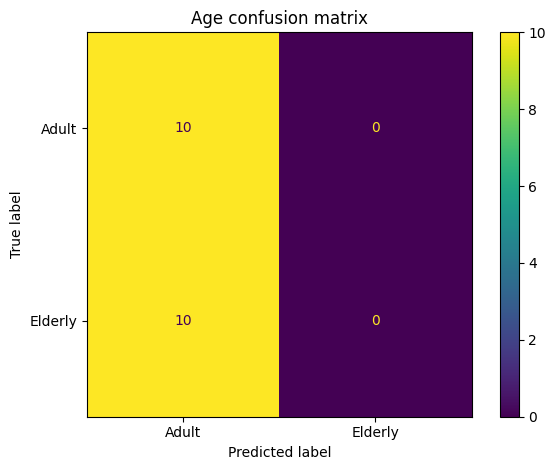

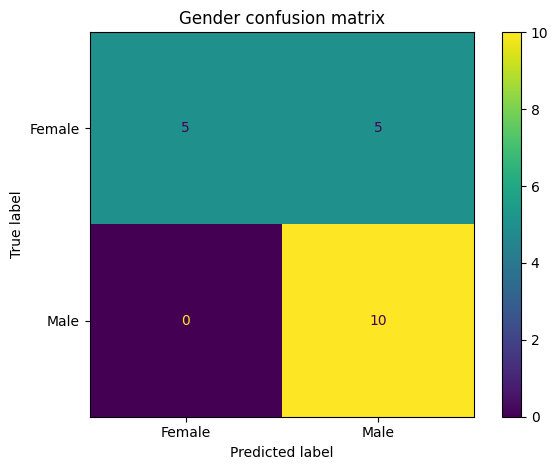

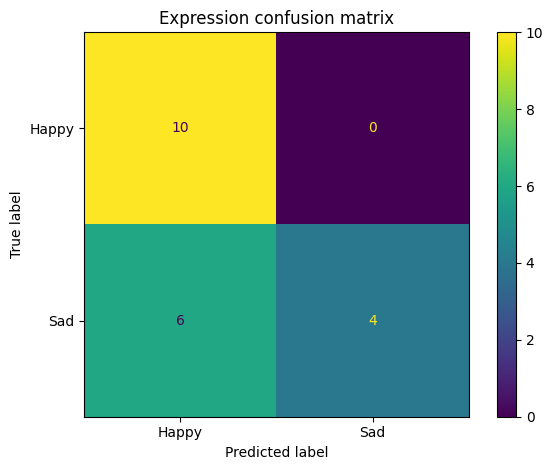

In [12]:
for task, columns in tasks.items():
    actual_col, predicted_col = columns
    labels = sorted(successful[actual_col].unique())

    cm = confusion_matrix(
        successful[actual_col],
        successful[predicted_col],
        labels=labels
    )

    ConfusionMatrixDisplay(cm, display_labels=labels).plot()
    plt.title(f"{task} confusion matrix")
    plt.tight_layout()
    plt.savefig(f"/content/{task.lower()}_confusion_matrix.png", dpi=200)
    plt.show()

## Misclassified images


In [13]:
wrong = successful[
    (successful["actual_age_group"] != successful["predicted_age_group"]) |
    (successful["actual_gender"] != successful["predicted_gender"]) |
    (successful["actual_expression"] != successful["predicted_expression"])
]

wrong

,image_id,filename,actual_age_group,predicted_age,predicted_age_group,actual_gender,predicted_gender,actual_expression,deepface_emotion,predicted_expression,happy_score,sad_score,inference_ms,status
4,IMG05,IMG05.jpg,Adult,39,Adult,Male,Male,Sad,Neutral,Happy,14.495330,0.210504,7423.115741,Success
7,IMG08,IMG08.jpg,Adult,29,Adult,Female,Male,Happy,Happy,Happy,99.999985,0.000007,7914.986565,Success
8,IMG09,IMG09.jpg,Adult,29,Adult,Female,Female,Sad,Happy,Happy,88.148468,0.002774,6293.223887,Success
9,IMG10,IMG10.jpg,Adult,43,Adult,Female,Female,Sad,Happy,Happy,47.301819,1.897353,8230.981711,Success
10,IMG11,IMG11.jpg,Elderly,33,Adult,Male,Male,Happy,Happy,Happy,96.915764,0.129796,6865.128107,Success
11,IMG12,IMG12.jpg,Elderly,35,Adult,Male,Male,Happy,Happy,Happy,97.514938,0.028062,7308.594693,Success
12,IMG13,IMG13.jpg,Elderly,42,Adult,Male,Male,Sad,Sad,Sad,0.023364,68.393669,6979.825433,Success
13,IMG14,IMG14.jpg,Elderly,35,Adult,Male,Male,Sad,Fear,Happy,11.289338,8.411710,7686.740370,Success
14,IMG15,IMG15.jpg,Elderly,55,Adult,Female,Male,Happy,Happy,Happy,65.044846,0.005939,6791.704690,Success
15,IMG16,IMG16.jpg,Elderly,54,Adult,Female,Male,Happy,Happy,Happy,58.202415,0.084684,8018.820359,Success


In [14]:
wrong.to_csv("/content/deepface_misclassified.csv", index=False)

## Download the results


In [15]:
from google.colab import files

os.makedirs("/content/deepface_outputs", exist_ok=True)

output_files = [
    "deepface_predictions.csv",
    "deepface_metrics.csv",
    "deepface_misclassified.csv",
    "age_confusion_matrix.png",
    "gender_confusion_matrix.png",
    "expression_confusion_matrix.png"
]

for file_name in output_files:
    source = os.path.join("/content", file_name)
    if os.path.exists(source):
        shutil.copy(source, "/content/deepface_outputs")

shutil.make_archive(
    "/content/deepface_outputs",
    "zip",
    "/content/deepface_outputs"
)

files.download("/content/deepface_outputs.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>